In [1]:
# Data handling
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sn
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
df = pd.read_csv("/content/ToyotaCorolla - MLR.csv")

In [3]:
print(df.head())

   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  


In [4]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None


In [7]:
# Check missing values
print(df.isnull().sum())

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


Exploratory Data Analysis (EDA)

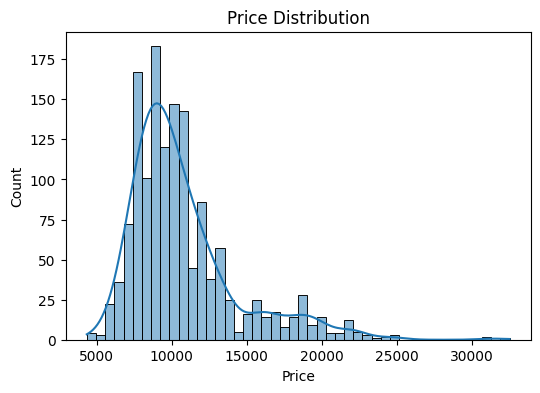

In [10]:
#Price Distribution
plt.figure(figsize=(6,4))
sn.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.show()

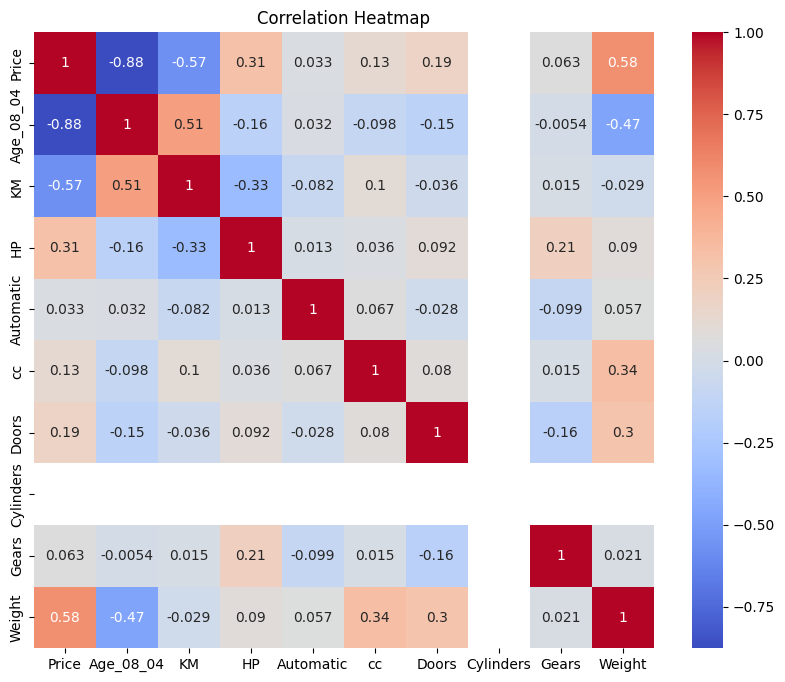

In [12]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sn.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

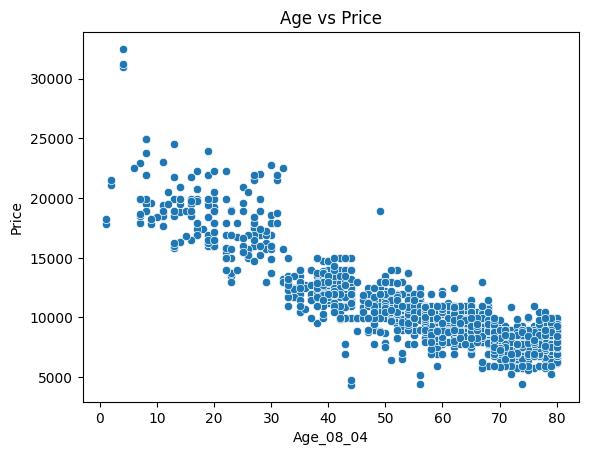

In [13]:
#Age vs Price
sn.scatterplot(x='Age_08_04',
                y='Price',
                data=df)

plt.title("Age vs Price")
plt.show()

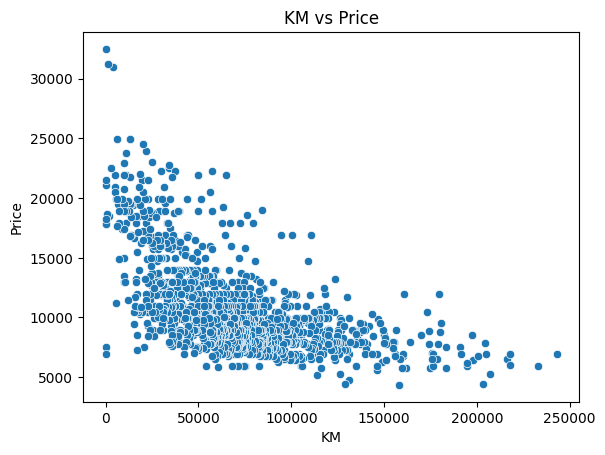

In [15]:
#KM vs Price
sn.scatterplot(x='KM',
                y='Price',
                data=df)

plt.title("KM vs Price")
plt.show()

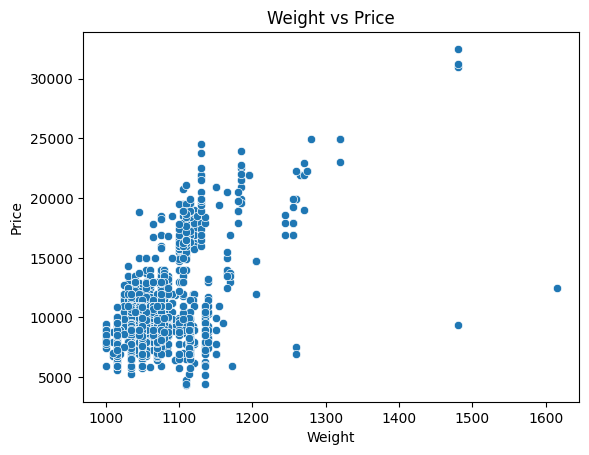

In [16]:
#Weight vs Price
sn.scatterplot(x='Weight',
                y='Price',
                data=df)

plt.title("Weight vs Price")
plt.show()

Data Preprocessing

In [17]:
#Convert Fuel Type into Numeric
encoder = LabelEncoder()

df['Fuel_Type'] = encoder.fit_transform(df['Fuel_Type'])

In [21]:
X = df.drop('Price', axis=1)

y = df['Price']

In [22]:
#Train-Test Split (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (1148, 10)
Testing Data : (288, 10)


Multiple Linear Regression

In [23]:
#Model 1
model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

In [24]:
#Coefficients
coef = pd.DataFrame({"Feature": X.columns,"Coefficient": model1.coef_})
print(coef)

     Feature  Coefficient
0  Age_08_04  -121.436240
1         KM    -0.016936
2  Fuel_Type   862.056431
3         HP    20.658283
4  Automatic   245.196891
5         cc    -0.073515
6      Doors   -36.279648
7  Cylinders     0.000000
8      Gears   530.282040
9     Weight    23.510643


In [25]:
print("Model 1 Results")
print("MAE :", mean_absolute_error(y_test, y_pred1))
print("MSE :", mean_squared_error(y_test, y_pred1))
print("RMSE :",np.sqrt(mean_squared_error(y_test, y_pred1)))
print("R2 Score :",r2_score(y_test, y_pred1))

Model 1 Results
MAE : 992.8982858371419
MSE : 2096851.1400177048
RMSE : 1448.0508071258082
R2 Score : 0.8428476112018002


In [26]:
#Model 2
X2 = df[['Age_08_04','KM','HP','Weight']]

In [27]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y,test_size=0.20,random_state=42)
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
y_pred2 = model2.predict(X2_test)
print("Model 2 R2 Score :",r2_score(y2_test, y_pred2))

Model 2 R2 Score : 0.8506068681500583


In [29]:
#Model 3 – Without KM
X3 = df[['Age_08_04','Fuel_Type','HP','Automatic','cc','Doors','Weight']]

In [30]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3,y,test_size=0.20,random_state=42)
model3 = LinearRegression()
model3.fit(X3_train, y3_train)
y_pred3 = model3.predict(X3_test)
print("Model 3 R2 Score :",r2_score(y3_test, y_pred3))

Model 3 R2 Score : 0.8209617102289906


In [31]:
#Standardization
#Required for Ridge and Lasso.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
#Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
print("Ridge R2 Score :",r2_score(y_test, ridge_pred))

Ridge R2 Score : 0.8428983416680236


In [33]:
#Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
print("Lasso R2 Score :",r2_score(y_test, lasso_pred))

Lasso R2 Score : 0.8428573741721097


In [37]:
#Compare All Models
results = pd.DataFrame({
    "Model":[
        "Model 1",
        "Model 2",
        "Model 3",
        "Ridge",
        "Lasso"
    ],
    "R2 Score":[
        r2_score(y_test,y_pred1),
        r2_score(y2_test,y_pred2),
        r2_score(y3_test,y_pred3),
        r2_score(y_test,ridge_pred),
        r2_score(y_test,lasso_pred)
    ]
})
print(results)

     Model  R2 Score
0  Model 1  0.842848
1  Model 2  0.850607
2  Model 3  0.820962
3    Ridge  0.842898
4    Lasso  0.842857


In [ ]:
from scipy.sparse.linalg import use_solver
###
Normalization scales data between 0 and 1.
usages
1)Removes scale differences
2)Improves model performance

In [ ]:
Standardization converts data to:
Mean = 0
Standard Deviation = 1

usages
1)Handles different feature scales
2)Required for Ridge and Lasso

In [ ]:
1)Remove highly correlated variables.
2)Use Correlation Matrix.
3)Apply Ridge Regression.
4)Apply Lasso Regression.
5)Collect more data.